In [ ]:
import pandas as pd
import numpy as np

from typing import List

import re

from collections import defaultdict
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import json
from typing import List, Any, Set, Dict
from tqdm import tqdm
import re
sns.set()
import math

## Load all reports

In [2]:
import json
import glob
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm  # Make sure to install this: !pip install tqdm

def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

if __name__ == '__main__':
    file_pattern = "data/*.json"
    files = glob.glob(file_pattern)
    
    data_list = []
    
    # We use a context manager for the executor
    with ProcessPoolExecutor() as executor:
        # map() returns an iterator; we wrap it with tqdm to get the progress bar
        # total=len(files) helps tqdm estimate the time remaining
        report_folder = 'outputs/reports/offline_wcd_igraph'
        report_files = glob.glob(report_folder + "/*.json")
        results = executor.map(load_json, report_files)
        
        # This loop pulls results from the pool as they finish
        for result in tqdm(results, total=len(report_files), desc="Loading JSONs"):
            data_list.append(result)
            
    print(f"Finished loading {len(data_list)} files.")

Loading JSONs: 100%|██████████| 4176/4176 [00:57<00:00, 72.33it/s] 

Finished loading 4176 files.


## Find all legacy reports with no system prompt

In [3]:
prompt_file = "wildguard_prompts_larger.parquet"
prompts_df = pd.read_parquet(prompt_file)
prompts = prompts_df['prompt'].tolist()
harmful_prompts = prompts[:30]
non_harmful_prompts = prompts[30:]

# agg params
temperature = 0.4
top_p = 0.8

def agg_stats(prompt_list: List[str], temp: float, top_p: float):
    file_confirmed = 0
    wcds = defaultdict(list)
    pruned_masses = defaultdict(list)

    for prompt in tqdm(prompt_list, desc="Processing prompts"):
        # find the file corresponding to the prompt
        for report in data_list:
            if True:
                if re.sub(r'[^a-zA-Z0-9]', '', report["prompt"].strip()) == re.sub(r'[^a-zA-Z0-9]', '', prompt.strip()) and float(report["temperature"]) == temp and float(report["top_p"]) == top_p and "system_prompt_id" not in report:  # match
                    file_confirmed += 1
                    intervention = report["interventions"][0]

                    if intervention["intervention"] == "none":
                        intervention_slug = "none"
                    else:
                        intervention_slug = str(intervention["intervention"]) + "_" + str(intervention["k"]) + "_" + str(intervention['selection']) + "_" + str(intervention['top_n'])

                    wcds[intervention_slug].append(intervention["wcd"] if intervention["wcd"] > 0 else 0)
                    pruned_masses[intervention_slug].append(intervention["mass_nucleus_after_intervention"])
    print(file_confirmed)
    return wcds, pruned_masses

harmful_wcds, harmful_pruned_masses = agg_stats(harmful_prompts, temperature, top_p)
non_harmful_wcds, non_harmful_pruned_masses = agg_stats(non_harmful_prompts, temperature, top_p)

Processing prompts: 100%|██████████| 30/30 [00:05<00:00,  5.77it/s]


870


Processing prompts: 100%|██████████| 30/30 [00:04<00:00,  6.24it/s]

870


## Find all new reports with system prompt

In [4]:
# agg params
temperature = 0.4
top_p = 0.8

def agg_stats(prompt_list: List[str], temp: float, top_p: float):
    file_confirmed = 0
    wcds = defaultdict(list)
    pruned_masses = defaultdict(list)

    for prompt in tqdm(prompt_list, desc="Processing prompts"):
        # find the file corresponding to the prompt
        for report in data_list:
            if True:
                if re.sub(r'[^a-zA-Z0-9]', '', prompt.strip()) in re.sub(r'[^a-zA-Z0-9]', '', report["prompt"].strip()) and float(report["temperature"]) == temp and float(report["top_p"]) == top_p and "system_prompt_id" in report and report["system_prompt_id"] == "safety_system_prompt":  # match
                    file_confirmed += 1
                    intervention = report["interventions"][0]

                    if intervention["intervention"] == "none":
                        intervention_slug = "none"
                    else:
                        intervention_slug = str(intervention["intervention"]) + "_" + str(intervention["k"]) + "_" + str(intervention['selection']) + "_" + str(intervention['top_n'])

                    wcds[intervention_slug].append(intervention["wcd"] if intervention["wcd"] > 0 else 0)
                    pruned_masses[intervention_slug].append(intervention["mass_nucleus_after_intervention"])
    print(file_confirmed)
    return wcds, pruned_masses

safety_harmful_wcds, safety_harmful_pruned_masses = agg_stats(harmful_prompts, temperature, top_p)
safety_non_harmful_wcds, safety_non_harmful_pruned_masses = agg_stats(non_harmful_prompts, temperature, top_p)

Processing prompts: 100%|██████████| 30/30 [00:05<00:00,  5.88it/s]


870


Processing prompts: 100%|██████████| 30/30 [00:04<00:00,  6.01it/s]

870


## Transform to DF

In [5]:
import pandas as pd
harmful_wcds_df = pd.DataFrame(harmful_wcds)
non_harmful_wcds_df = pd.DataFrame(non_harmful_wcds)
harmful_pruned_masses_df = pd.DataFrame(harmful_pruned_masses)
non_harmful_pruned_masses_df = pd.DataFrame(non_harmful_pruned_masses)

harmful_wcds_df["system_prompt"] = safety_harmful_wcds["none"]
non_harmful_wcds_df["system_prompt"] = safety_non_harmful_wcds["none"]
harmful_pruned_masses_df["system_prompt"] = safety_harmful_pruned_masses["none"]
non_harmful_pruned_masses_df["system_prompt"] = safety_non_harmful_pruned_masses["none"]

cols = [
    col
    for col in harmful_wcds_df.columns
    if "30" not in col and "40" not in col and "random" not in col  # only finished experiments for some of prompts so we filter out the rest
]

harmful_wcds_df = harmful_wcds_df / harmful_wcds_df["none"].values[:, None]
non_harmful_wcds_df = non_harmful_wcds_df / non_harmful_wcds_df["none"].values[:, None]
harmful_pruned_masses_df = harmful_pruned_masses_df / harmful_pruned_masses_df["none"].values[:, None]
non_harmful_pruned_masses_df = non_harmful_pruned_masses_df / non_harmful_pruned_masses_df["none"].values[:, None]

harmful_wcds_df = harmful_wcds_df[cols]
non_harmful_wcds_df = non_harmful_wcds_df[cols]
harmful_pruned_masses_df = harmful_pruned_masses_df[cols]
non_harmful_pruned_masses_df = non_harmful_pruned_masses_df[cols]
combined_wcds_df = pd.concat([harmful_wcds_df, non_harmful_wcds_df], axis=0).reset_index(drop=True)
combined_pruned_masses_df = pd.concat([harmful_pruned_masses_df, non_harmful_pruned_masses_df], axis=0).reset_index(drop=True)

In [6]:
combined_wcds_df.shape

(60, 12)

In [7]:
import pandas as pd
safety_harmful_wcds_df = pd.DataFrame(safety_harmful_wcds)
safety_non_harmful_wcds_df = pd.DataFrame(safety_non_harmful_wcds)
safety_harmful_pruned_masses_df = pd.DataFrame(safety_harmful_pruned_masses)
safety_non_harmful_pruned_masses_df = pd.DataFrame(safety_non_harmful_pruned_masses)

cols = [
    col
    for col in safety_harmful_wcds_df.columns
    if "30" not in col and "40" not in col and "random" not in col  # only finished experiments for some of prompts so we filter out the rest
]
safety_harmful_wcds_df = safety_harmful_wcds_df / safety_harmful_wcds_df["none"].values[:, None]
safety_non_harmful_wcds_df = safety_non_harmful_wcds_df / safety_non_harmful_wcds_df["none"].values[:, None]
safety_harmful_pruned_masses_df = safety_harmful_pruned_masses_df / safety_harmful_pruned_masses_df["none"].values[:, None]
safety_non_harmful_pruned_masses_df = safety_non_harmful_pruned_masses_df / safety_non_harmful_pruned_masses_df["none"].values[:, None]

safety_harmful_wcds_df = safety_harmful_wcds_df[cols]
safety_non_harmful_wcds_df = safety_non_harmful_wcds_df[cols]
safety_harmful_pruned_masses_df = safety_harmful_pruned_masses_df[cols]
safety_non_harmful_pruned_masses_df = safety_non_harmful_pruned_masses_df[cols]
combined_safety_wcds_df = pd.concat([safety_harmful_wcds_df, safety_non_harmful_wcds_df], axis=0).reset_index(drop=True)
combined_safety_pruned_masses_df = pd.concat([safety_harmful_pruned_masses_df, safety_non_harmful_pruned_masses_df], axis=0).reset_index(drop=True)

In [8]:
combined_safety_wcds_df.shape

(60, 11)

## Overall results

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Baseline column
baseline_col = "none"

# Test only intervention columns.
# Exclude the baseline itself and system_prompt because it is a separate
# distribution-changing comparator rather than a fixed-graph intervention.
intervention_cols = [
    col
    for col in combined_wcds_df.columns
    if col not in {baseline_col, "system_prompt"}
]

results = []

for col in intervention_cols:
    paired = combined_wcds_df[[baseline_col, col]].dropna()

    baseline = paired[baseline_col].to_numpy()
    intervention = paired[col].to_numpy()

    # Paired differences: positive values mean the intervention reduced WCD.
    differences = baseline - intervention
    nonzero_count = np.count_nonzero(differences)

    if nonzero_count == 0:
        # scipy raises an error when every paired difference is zero.
        statistic = 0.0
        p_value = 1.0
    else:
        test = wilcoxon(
            baseline,
            intervention,
            alternative="greater",  # tests baseline > intervention
            zero_method="pratt",    # handles the many zero differences
            method="auto",
        )
        statistic = test.statistic
        p_value = test.pvalue

    success_mask = intervention < baseline

    results.append(
        {
            "intervention": col,
            "n_reductions": int(success_mask.sum()),
            "success_rate": success_mask.mean(),
            "mean_rho_wcd_all": intervention.mean(),
            "mean_rho_wcd_successes": (
                intervention[success_mask].mean()
                if success_mask.any()
                else np.nan
            ),
            "wilcoxon_statistic": statistic,
            "p_value_raw": p_value,
        }
    )

results_df = pd.DataFrame(results)

# Holm-Bonferroni correction across all intervention-depth comparisons.
reject, p_adjusted, _, _ = multipletests(
    results_df["p_value_raw"],
    alpha=0.05,
    method="holm",
)

results_df["p_value_holm"] = p_adjusted
results_df["significant_holm_0.05"] = reject

# Optional significance markers for the paper table.
results_df["significance"] = np.select(
    [
        results_df["p_value_holm"] < 0.001,
        results_df["p_value_holm"] < 0.01,
        results_df["p_value_holm"] < 0.05,
    ],
    ["***", "**", "*"],
    default="",
)

results_df = results_df.sort_values(
    ["p_value_holm", "intervention"]
).reset_index(drop=True)

results_df

,intervention,n_reductions,success_rate,mean_rho_wcd_all,mean_rho_wcd_successes,wilcoxon_statistic,p_value_raw,p_value_holm,significant_holm_0.05,significance
0,fixed_k_10_extreme_1,10,0.169492,0.974198,0.847770,545.0,0.000795,0.007946,True,**
1,fixed_k_10_max_1,10,0.169492,0.967595,0.808811,545.0,0.000795,0.007946,True,**
2,fixed_k_10_min_1,9,0.152542,0.979923,0.868383,495.0,0.001365,0.010916,True,*
3,fixed_k_20_extreme_1,9,0.152542,0.972167,0.817539,495.0,0.001364,0.010916,True,*
4,fixed_k_20_min_1,8,0.135593,0.978814,0.843751,444.0,0.002356,0.014138,True,*
5,fixed_k_20_max_1,7,0.118644,0.978863,0.821842,392.0,0.004096,0.020479,True,*
6,fixed_k_10_both_sides_1,4,0.067797,0.991522,0.874947,230.0,0.022771,0.091082,False,
7,fixed_k_10_extreme_3,1,0.016949,0.997823,0.871560,59.0,0.158655,0.475966,False,
8,fixed_k_20_both_sides_1,0,0.000000,1.000000,NaN,0.0,1.000000,1.000000,False,
9,fixed_k_20_extreme_3,0,0.000000,1.000000,NaN,0.0,1.000000,1.000000,False,


## Get aggregates for overleaf

In [10]:
## success rate
print("Success Rate for Combined WCDs:")
print("=========================")
for col in combined_wcds_df.columns:
    print(col, "success rate:", round((combined_wcds_df[col] < 1).mean(), 2))


# wcd reduction
print("\nMean WCD Reduction for Combined WCDs:")
print("=========================")
for col in combined_wcds_df.columns:
    print(col, "mean WCD reduction:", round(combined_wcds_df[combined_wcds_df[col] < 1][col].mean(), 2))

# probability mass reduction
print("\nMean Probability Mass Reduction for Combined Pruned Masses:")
print("=========================")
for col in combined_pruned_masses_df.columns:
    print(col, "mean probability mass reduction:", round(combined_pruned_masses_df[combined_wcds_df[col] < 1][col].mean(), 2))

Success Rate for Combined WCDs:
fixed_k_10_extreme_3 success rate: 0.02
fixed_k_20_min_1 success rate: 0.13
fixed_k_10_max_1 success rate: 0.17
fixed_k_10_extreme_1 success rate: 0.17
fixed_k_20_extreme_3 success rate: 0.0
fixed_k_20_max_1 success rate: 0.12
fixed_k_20_both_sides_1 success rate: 0.0
fixed_k_10_min_1 success rate: 0.15
fixed_k_10_both_sides_1 success rate: 0.07
fixed_k_20_extreme_1 success rate: 0.15
none success rate: 0.0
system_prompt success rate: 0.42

Mean WCD Reduction for Combined WCDs:
fixed_k_10_extreme_3 mean WCD reduction: 0.87
fixed_k_20_min_1 mean WCD reduction: 0.84
fixed_k_10_max_1 mean WCD reduction: 0.81
fixed_k_10_extreme_1 mean WCD reduction: 0.85
fixed_k_20_extreme_3 mean WCD reduction: nan
fixed_k_20_max_1 mean WCD reduction: 0.82
fixed_k_20_both_sides_1 mean WCD reduction: nan
fixed_k_10_min_1 mean WCD reduction: 0.87
fixed_k_10_both_sides_1 mean WCD reduction: 0.87
fixed_k_20_extreme_1 mean WCD reduction: 0.82
none mean WCD reduction: nan
system_p

In [11]:
## success rate
print("Success Rate for Combined WCDs:")
print("=========================")
for col in combined_safety_wcds_df.columns:
    print(col, "success rate:", round((combined_safety_wcds_df[col] < 1).mean(), 2))


# wcd reduction
print("\nMean WCD Reduction for Combined WCDs:")
print("=========================")
for col in combined_safety_wcds_df.columns:
    print(col, "mean WCD reduction:", round(combined_safety_wcds_df[combined_safety_wcds_df[col] < 1][col].mean(), 2))

# probability mass reduction
print("\nMean Probability Mass Reduction for Combined Pruned Masses:")
print("=========================")
for col in combined_safety_pruned_masses_df.columns:
    print(col, "mean probability mass reduction:", round(combined_safety_pruned_masses_df[combined_safety_wcds_df[col] < 1][col].mean(), 2))

Success Rate for Combined WCDs:
fixed_k_20_extreme_1 success rate: 0.1
fixed_k_10_extreme_1 success rate: 0.17
fixed_k_20_min_1 success rate: 0.1
fixed_k_10_both_sides_1 success rate: 0.02
fixed_k_10_extreme_3 success rate: 0.0
fixed_k_20_both_sides_1 success rate: 0.0
fixed_k_10_min_1 success rate: 0.13
fixed_k_20_extreme_3 success rate: 0.0
none success rate: 0.0
fixed_k_10_max_1 success rate: 0.15
fixed_k_20_max_1 success rate: 0.12

Mean WCD Reduction for Combined WCDs:
fixed_k_20_extreme_1 mean WCD reduction: 0.8
fixed_k_10_extreme_1 mean WCD reduction: 0.91
fixed_k_20_min_1 mean WCD reduction: 0.8
fixed_k_10_both_sides_1 mean WCD reduction: 0.91
fixed_k_10_extreme_3 mean WCD reduction: nan
fixed_k_20_both_sides_1 mean WCD reduction: nan
fixed_k_10_min_1 mean WCD reduction: 0.9
fixed_k_20_extreme_3 mean WCD reduction: nan
none mean WCD reduction: nan
fixed_k_10_max_1 mean WCD reduction: 0.85
fixed_k_20_max_1 mean WCD reduction: 0.8

Mean Probability Mass Reduction for Combined Pru

## System prompt WCD

Plot saved as 'metric_hist.png' with 0.25 bins and 2+ clamping.


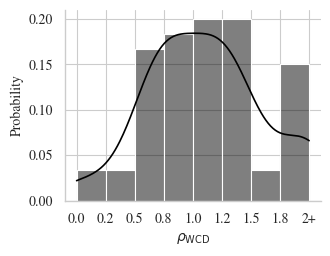

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare data: Clamp values >= 2 to 2
# This puts all "2 and above" values into the final bin
clamped_series = combined_wcds_df['system_prompt'].clip(upper=2)

# 2. Setup Plot
width_in_inches = 3.3
fig, ax = plt.subplots(figsize=(width_in_inches, width_in_inches * 0.75))

# 3. Plotting
# Use defined bins (0 to 2 in 0.25 increments)
bins = np.arange(0, 2 + 0.25, 0.25)
sns.histplot(clamped_series, bins=bins, kde=True, ax=ax, color='black', stat="probability")

# 4. Custom Ticks
# Set x-ticks from 0 to 2 with 0.25 steps
ax.set_xticks(np.arange(0, 2 + 0.1, 0.25))
# Optional: Label the final tick as "2+"
labels = [f"{x:.1f}" for x in np.arange(0, 2, 0.25)] + ["2+"]
ax.set_xticklabels(labels)

# 5. Styling
sns.set_style("ticks")
sns.despine()
ax.set_xlabel(r"$\rho_{\mathrm{WCD}}$")
ax.set_ylabel("Probability")

# 6. Save
plt.rcParams.update({
    "font.family": "serif",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
plt.savefig("metric_hist.png", bbox_inches='tight', dpi=600)
print("Plot saved as 'metric_hist.png' with 0.25 bins and 2+ clamping.")

## Stability section

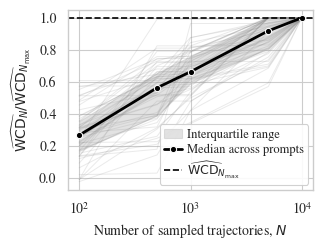

,sample_size_used,median,mean,q25,q75,count
0,100,0.266055,0.274014,0.170805,0.353966,59
1,500,0.562500,0.532322,0.390091,0.654896,59
2,1000,0.662791,0.669001,0.590718,0.759907,59
3,5000,0.918605,0.886142,0.810667,1.000000,59
4,10000,1.000000,1.000000,1.000000,1.000000,59


In [31]:
from pathlib import Path


# Folder containing the per-prompt CSV files.
CSV_FOLDER = Path("./outputs/reports/offline_wcd_igraph_baseline_samples/")

# PDF output.
OUTPUT_PATH = "./wcd_stability_normalized.png"


required_columns = {
    "jsonl_file",
    "sample_size_used",
    "baseline_wcd",
}

csv_files = sorted(CSV_FOLDER.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {CSV_FOLDER}")

frames = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        print(
            f"Skipping {csv_file.name}: "
            f"missing {sorted(missing_columns)}"
        )
        continue

    frames.append(df)

if not frames:
    raise ValueError("No valid CSV files were found.")

data = pd.concat(frames, ignore_index=True)

data["sample_size_used"] = pd.to_numeric(
    data["sample_size_used"],
    errors="coerce",
)
data["baseline_wcd"] = pd.to_numeric(
    data["baseline_wcd"],
    errors="coerce",
)

data = data.dropna(
    subset=["jsonl_file", "sample_size_used", "baseline_wcd"]
)

data["sample_size_used"] = data["sample_size_used"].astype(int)

# Average repeated runs for the same prompt and sample size.
# This also supports multiple seeds.
data = (
    data.groupby(
        ["jsonl_file", "sample_size_used"],
        as_index=False,
    )
    .agg(baseline_wcd=("baseline_wcd", "mean"))
)

# Find the WCD at the largest available sample size for each prompt.
largest_sample = (
    data.sort_values("sample_size_used")
    .groupby("jsonl_file", as_index=False)
    .tail(1)
    [["jsonl_file", "baseline_wcd"]]
    .rename(columns={"baseline_wcd": "largest_sample_wcd"})
)

data = data.merge(
    largest_sample,
    on="jsonl_file",
    how="left",
)

# Exclude prompts for which normalization is undefined.
num_zero_wcd = data.loc[
    data["largest_sample_wcd"] == 0,
    "jsonl_file",
].nunique()

if num_zero_wcd:
    print(
        f"Excluding {num_zero_wcd} prompts whose "
        "largest-sample WCD is zero."
    )

data = data[data["largest_sample_wcd"] > 0].copy()

data["relative_wcd"] = (
    data["baseline_wcd"] / data["largest_sample_wcd"]
)

# Compute summary statistics across prompts.
summary = (
    data.groupby("sample_size_used")["relative_wcd"]
    .agg(
        median="median",
        mean="mean",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        count="count",
    )
    .reset_index()
    .sort_values("sample_size_used")
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    # Times-like serif font where available.
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "Nimbus Roman",
        "Liberation Serif",
        "DejaVu Serif",
    ],

    # Avoid Type 3 fonts in the exported PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # AAAI requires text inside figures to be at least 9 pt.
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

# AAAI single-column width is approximately 3.3 inches.
width_in_inches = 3.3

fig, ax = plt.subplots(
    figsize=(width_in_inches, width_in_inches * 0.78)
)

# One faint line per prompt.
# Gray rather than color so the figure works directly in grayscale.
sns.lineplot(
    data=data,
    x="sample_size_used",
    y="relative_wcd",
    units="jsonl_file",
    estimator=None,
    linewidth=0.7,
    alpha=0.18,
    color="0.55",
    legend=False,
    ax=ax,
)

# Interquartile range.
ax.fill_between(
    summary["sample_size_used"],
    summary["q25"],
    summary["q75"],
    color="0.75",
    alpha=0.45,
    label="Interquartile range",
)

# Median across prompts.
sns.lineplot(
    data=summary,
    x="sample_size_used",
    y="median",
    marker="o",
    markersize=4.5,
    linewidth=2.0,
    color="black",
    label="Median across prompts",
    ax=ax,
)

# Reference value at the largest sample size.
ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=r"$\widehat{\mathrm{WCD}}_{N_{\max}}$",
)

ax.set_xscale("log")

ax.set_xlabel(
    r"Number of sampled trajectories, $N$"
)

ax.set_ylabel(
    r"$\widehat{\mathrm{WCD}}_N/"
    r"\widehat{\mathrm{WCD}}_{N_{\max}}$"
)

# Intentionally no title here.
# Put "Sample-Size Stability of Estimated WCD"
# in the LaTeX figure caption instead.

ax.legend(
    loc="lower right",
    fontsize=9,
    labelspacing=0.25,
    handlelength=1.4,
    handletextpad=0.4,
    borderpad=0.35,
    borderaxespad=0.4,
    frameon=True,
    framealpha=0.9,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH,
    bbox_inches="tight",
    dpi=600
)

plt.show()

display(summary)

In [3]:
import pandas as pd


# Summary statistics for every evaluated sample size.
stability_summary = (
    data.groupby("sample_size_used")["relative_wcd"]
    .agg(
        number_of_prompts="count",
        median="median",
        mean="mean",
        minimum="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        maximum="max",
        within_5_percent=lambda x: ((x >= 0.95) & (x <= 1.05)).mean(),
        within_10_percent=lambda x: ((x >= 0.90) & (x <= 1.10)).mean(),
    )
    .reset_index()
    .sort_values("sample_size_used")
)

# Convert proportions to percentages for readability.
stability_summary["within_5_percent"] *= 100
stability_summary["within_10_percent"] *= 100

display(stability_summary.round(4))

,sample_size_used,number_of_prompts,median,mean,minimum,q25,q75,maximum,within_5_percent,within_10_percent
0,100,59,0.2661,0.2740,-0.0238,0.1708,0.3540,0.6078,0.0000,0.0000
1,500,59,0.5625,0.5323,0.0294,0.3901,0.6549,0.9906,1.6949,1.6949
2,1000,59,0.6628,0.6690,0.3390,0.5907,0.7599,0.9906,3.3898,3.3898
3,5000,59,0.9186,0.8861,0.5706,0.8107,1.0000,1.0000,37.2881,52.5424
4,10000,59,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,100.0000,100.0000


In [4]:
n_report = 5000

row = stability_summary.loc[
    stability_summary["sample_size_used"] == n_report
].iloc[0]

print(f"Number of prompts: {int(row['number_of_prompts'])}")
print(f"Median: {row['median']:.3f}")
print(f"IQR: [{row['q25']:.3f}, {row['q75']:.3f}]")
print(f"Within 5%: {row['within_5_percent']:.1f}%")
print(f"Within 10%: {row['within_10_percent']:.1f}%")

Number of prompts: 59
Median: 0.919
IQR: [0.811, 1.000]
Within 5%: 37.3%
Within 10%: 52.5%


## Classifier metrics

In [3]:
from utils.harm import load_harm_detector

harm_detector = load_harm_detector('harm_detector/models/binary_harm_detector.dill')

/lv_local/home/omer.belsky/miniforge3/envs/grd_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
splits = {'train': 'Content Moderation Extracted Annotations 02.08.24_train_release_0418_v1.parquet', 'test': 'Content Moderation Extracted Annotations 02.08.24_test_release_0418_v1.parquet'}
aegis_train_df = pd.read_parquet("hf://datasets/nvidia/Aegis-AI-Content-Safety-Dataset-1.0/" + splits["train"])
aegis_test_df = pd.read_parquet("hf://datasets/nvidia/Aegis-AI-Content-Safety-Dataset-1.0/" + splits["test"])

# Clean aegis dataset from rows with multiple labels in single column
label_cols = [f"labels_{i}" for i in range(5)]
for col in label_cols:
    aegis_train_df = aegis_train_df[~aegis_train_df[col].fillna('').str.contains(", ")]
    aegis_test_df = aegis_test_df[~aegis_test_df[col].fillna('').str.contains(", ")]


# Preprocessing function according to Zheng et al. https://arxiv.org/pdf/2411.14398
def preprocess_aegis(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Reconcile multiple annotator labels into a single 'final_label' per row
    following the AEGIS scheme, then drop 'Needs Caution' and duplicate prompts.

    Parameters
    ----------
    df: pd.DataFrame
        original DataFrame with columns labels_0 … labels_4 and a 'text' column.
    seed: int
        random seed for reproducibility.

    Returns
    -------
        A new DataFrame with one consolidated 'final_label' column.
    """


    np.random.seed(seed)
    df = df.copy()

    label_cols = [f"labels_{i}" for i in range(5)]

    # paper uses labels_1 as the primary label w.l.o.g
    df["final_label"] = df["labels_1"]

    # Helper to gather all other labels for a row
    def other_votes(row):
        return [row[c] for c in label_cols if row[c] not in (None, np.nan)]

    # Replace “Other” if someone else labeled non-“Other”, else drop
    mask_other = df["final_label"] == "Other"
    for idx in df[mask_other].index:
        votes = other_votes(df.loc[idx])
        non_other = [v for v in votes if v != "Other"]
        if non_other:
            df.at[idx, "final_label"] = non_other[0]
        else:
            df.drop(idx, inplace=True)

    # Reconcile “Safe” labels:
    mask_safe = df["final_label"] == "Safe"
    for idx in df[mask_safe].index:
        votes = other_votes(df.loc[idx])
        unsafe_votes = [v for v in votes if v != "Safe"]
        if unsafe_votes:
            # pick one of the unsafe categories at random
            df.at[idx, "final_label"] = np.random.choice(unsafe_votes)
        # else: all agree on Safe, keep “Safe”


    # Remove “Needs Caution”
    df = df[~df["final_label"].isin(["Needs Caution", 'Other'])]

    # Drop duplicates by prompt text (keep first occurrence)
    df = df.drop_duplicates(subset="text", keep="first")

    return df.drop(columns=label_cols)


aegis_train_df = preprocess_aegis(aegis_train_df)
aegis_test_df = preprocess_aegis(aegis_test_df)

y_test = aegis_test_df['final_label'].notna()
y_train = aegis_train_df['final_label'] != 'Safe'
y_pred = harm_detector.predict_proba(aegis_test_df)[:, 1]

ROC AUC: 0.8843742962240072
F1 Score: 0.784503631961259
Precision: 0.8901098901098901
Recall: 0.7012987012987013


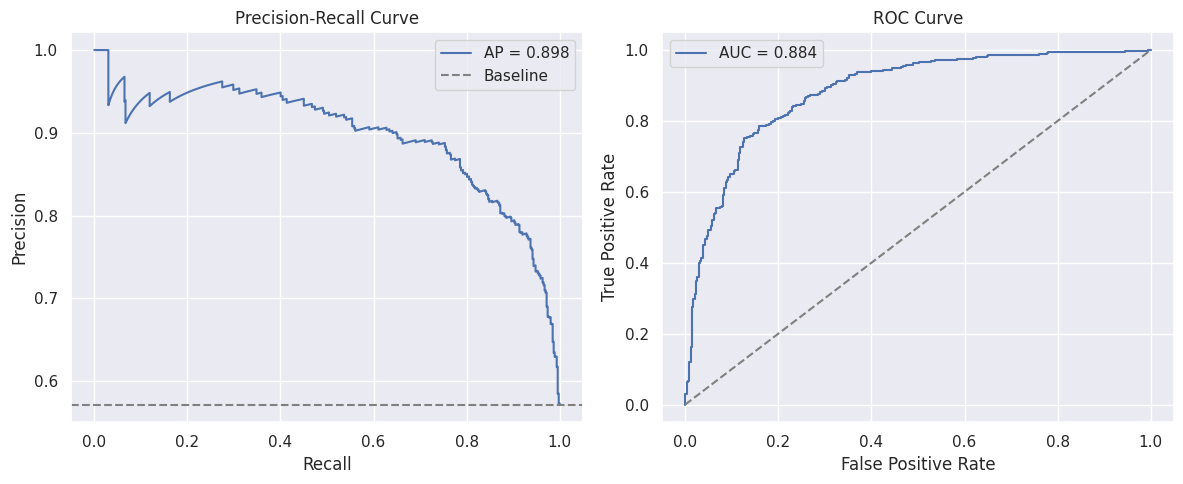

In [5]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score
def get_metrics(y_true, y_pred, tau=0.75):
    print("ROC AUC:", roc_auc_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred > tau))
    print("Precision:", precision_score(y_true, y_pred > tau))
    print("Recall:", recall_score(y_true, y_pred > tau))
    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # PR curve
    axes[0].plot(recall, precision, label=f"AP = {ap:.3f}")
    axes[0].axhline(y_true.mean(), linestyle="--", color="gray", label="Baseline")
    axes[0].set_title("Precision-Recall Curve")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].legend()

    # ROC curve
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
get_metrics(y_test, y_pred, tau=0.75)

In [23]:
wildguard_train_df = pd.read_parquet("hf://datasets/allenai/wildguardmix/train/wildguard_train.parquet")
wildguard_test_df = pd.read_parquet("hf://datasets/allenai/wildguardmix/test/wildguard_test.parquet")

In [28]:
wild_guard_prompts_test = wildguard_test_df.loc[wildguard_test_df["prompt_harm_label"].notna()]
wild_guard_prompts_test['label'] = wild_guard_prompts_test['prompt_harm_label'].apply(lambda x: 1 if x == 'harmful' else 0)
wild_guard_prompts_test = wild_guard_prompts_test[['prompt', 'label']].rename(columns={'prompt': 'text'})


wild_guard_response_test = wildguard_test_df.loc[wildguard_test_df["response_harm_label"].notna()]
wild_guard_response_test['label'] = wild_guard_response_test['response_harm_label'].apply(lambda x: 1 if x == 'harmful' else 0)
wild_guard_response_test = wild_guard_response_test[['response', 'label']].rename(columns={'response': 'text'})

In [32]:
batch_size = 32

y_prompt_pred = []
for i in range(0, len(wild_guard_prompts_test), batch_size):
    batch = wild_guard_prompts_test.iloc[i:i+batch_size]
    y_prompt_pred.extend(harm_detector.predict_proba(batch)[:, 1])

y_response_pred = []
for i in range(0, len(wild_guard_response_test), batch_size):
    batch = wild_guard_response_test.iloc[i:i+batch_size]
    y_response_pred.extend(harm_detector.predict_proba(batch)[:, 1])

y_prompt_pred = np.array(y_prompt_pred)
y_response_pred = np.array(y_response_pred)

ROC AUC: 0.7205100136134619
F1 Score: 0.5857860732232592
Precision: 0.6384976525821596
Recall: 0.5411140583554377


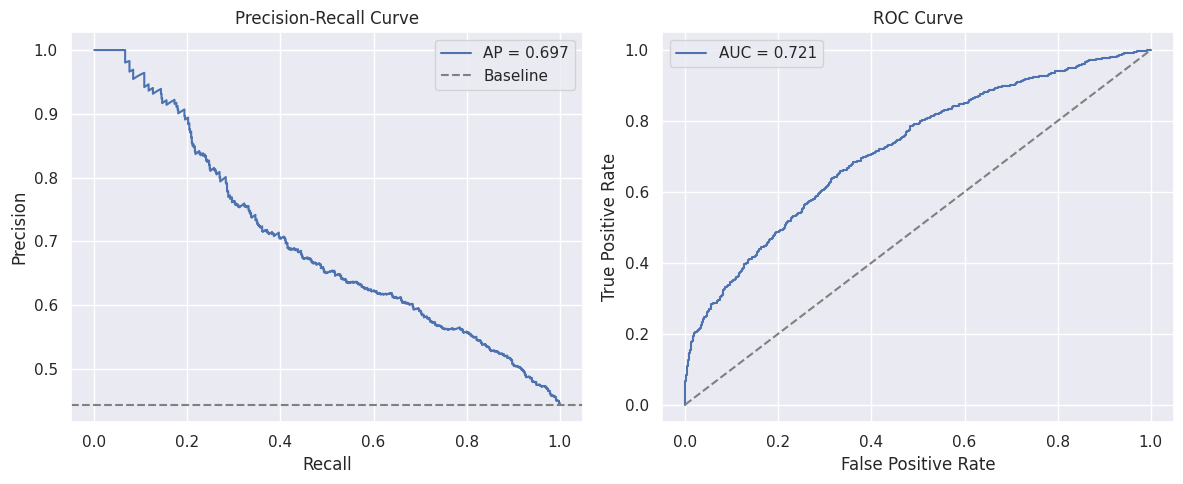

In [35]:
get_metrics(wild_guard_prompts_test['label'], y_prompt_pred, tau=0.75)

ROC AUC: 0.7104126513466765
F1 Score: 0.3973655323819978
Precision: 0.2886762360446571
Recall: 0.6373239436619719


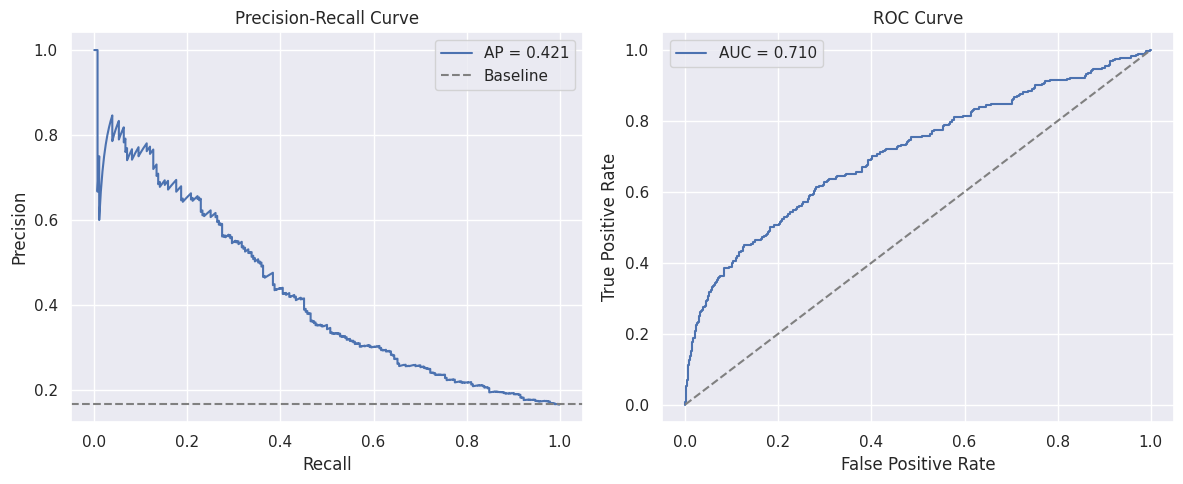

In [39]:
get_metrics(wild_guard_response_test['label'], y_response_pred, tau=0.75)